### 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [2]:
# Load the dataset
df = pd.read_csv('/content/credit_risk_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(df.head())
df

Dataset shape: (32581, 12)
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y    

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [3]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\nDataset Description:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None

Dataset Des

In [4]:
# Basic info
print(df.info())
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Check class distribution (loan_status)
print(df['loan_status'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None
         person_age  perso


STEP 2: EXPLORATORY DATA ANALYSIS


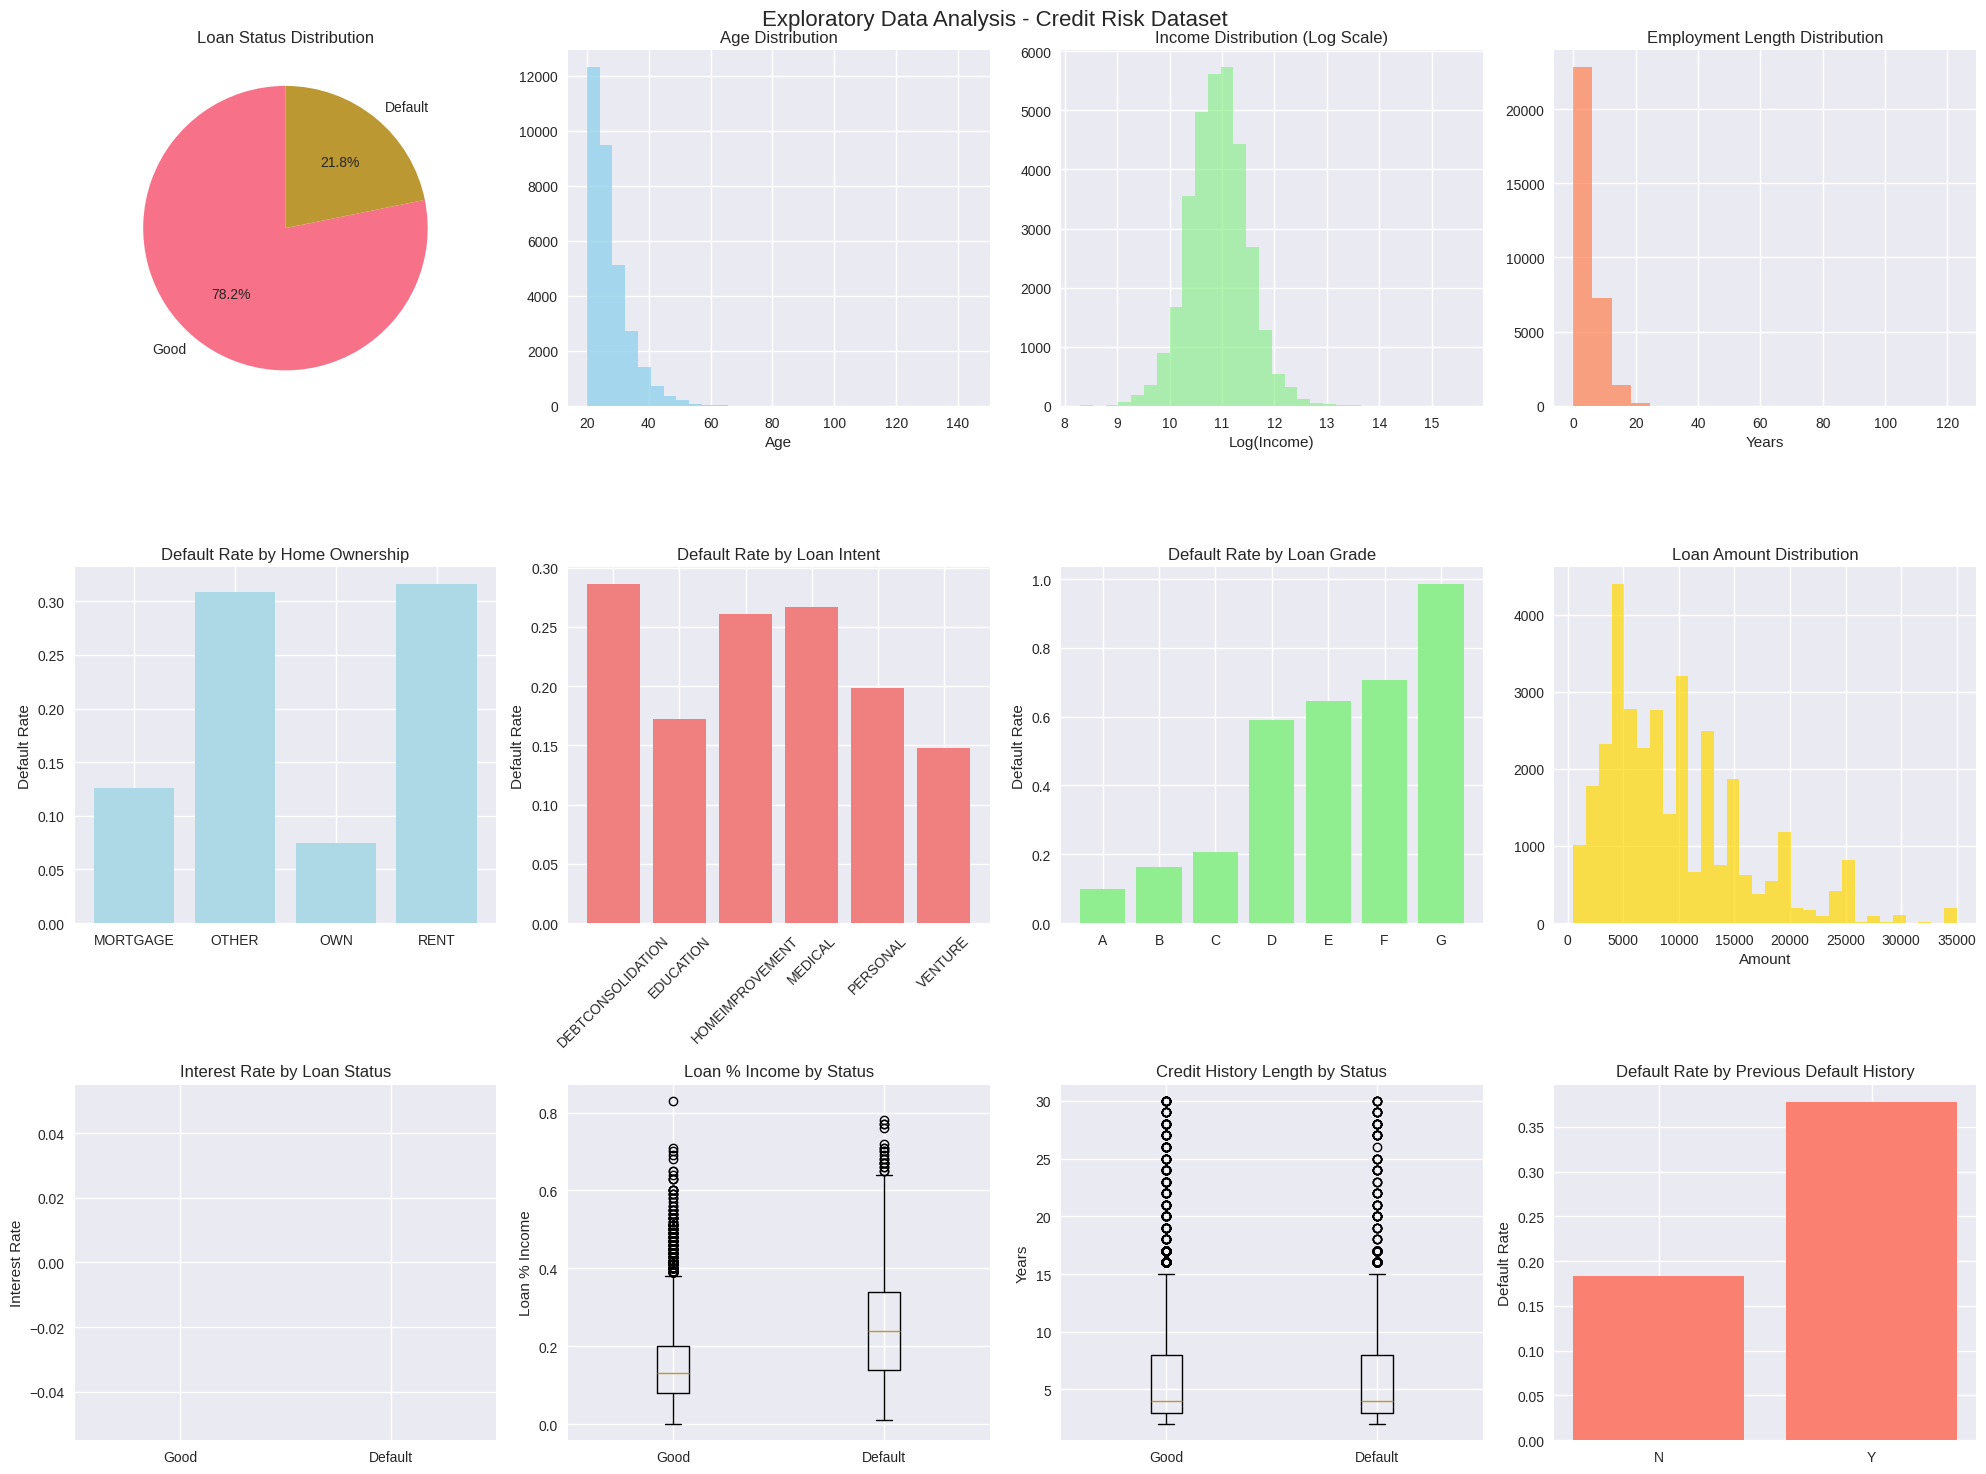


Correlation Analysis:


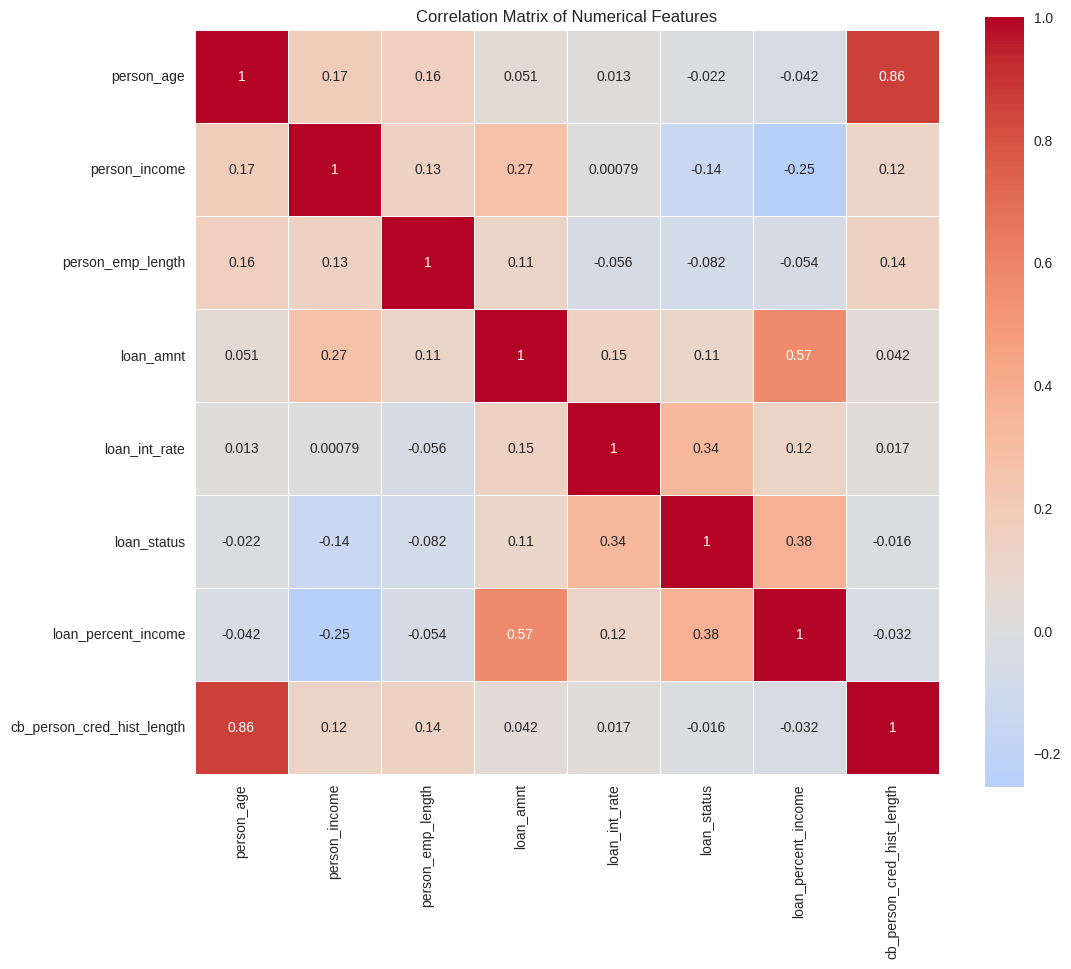


Key EDA Insights:
• Average default rate: 0.2182
• Highest default rate by grade: 0.9844 (Grade G)
• Lowest default rate by grade: 0.0996 (Grade A)
• Default rate with previous default: 0.3781
• Default rate without previous default: 0.1839


In [5]:
def perform_eda(df):
    """Comprehensive Exploratory Data Analysis"""
    print("\n" + "=" * 60)
    print("STEP 2: EXPLORATORY DATA ANALYSIS")
    print("=" * 60)

    # Set up the plotting area
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    fig.suptitle('Exploratory Data Analysis - Credit Risk Dataset', fontsize=16)

    # 1. Target variable distribution
    axes[0, 0].pie(df['loan_status'].value_counts(), labels=['Good', 'Default'],
                   autopct='%1.1f%%', startangle=90)
    axes[0, 0].set_title('Loan Status Distribution')

    # 2. Age distribution
    axes[0, 1].hist(df['person_age'], bins=30, alpha=0.7, color='skyblue')
    axes[0, 1].set_title('Age Distribution')
    axes[0, 1].set_xlabel('Age')

    # 3. Income distribution (log scale)
    axes[0, 2].hist(np.log(df['person_income']), bins=30, alpha=0.7, color='lightgreen')
    axes[0, 2].set_title('Income Distribution (Log Scale)')
    axes[0, 2].set_xlabel('Log(Income)')

    # 4. Employment length distribution
    axes[0, 3].hist(df['person_emp_length'].dropna(), bins=20, alpha=0.7, color='coral')
    axes[0, 3].set_title('Employment Length Distribution')
    axes[0, 3].set_xlabel('Years')

    # 5. Home ownership vs default rate
    home_default = df.groupby('person_home_ownership')['loan_status'].mean()
    axes[1, 0].bar(home_default.index, home_default.values, color='lightblue')
    axes[1, 0].set_title('Default Rate by Home Ownership')
    axes[1, 0].set_ylabel('Default Rate')

    # 6. Loan intent vs default rate
    intent_default = df.groupby('loan_intent')['loan_status'].mean()
    axes[1, 1].bar(intent_default.index, intent_default.values, color='lightcoral')
    axes[1, 1].set_title('Default Rate by Loan Intent')
    axes[1, 1].set_ylabel('Default Rate')
    axes[1, 1].tick_params(axis='x', rotation=45)

    # 7. Loan grade vs default rate
    grade_default = df.groupby('loan_grade')['loan_status'].mean()
    axes[1, 2].bar(grade_default.index, grade_default.values, color='lightgreen')
    axes[1, 2].set_title('Default Rate by Loan Grade')
    axes[1, 2].set_ylabel('Default Rate')

    # 8. Loan amount distribution
    axes[1, 3].hist(df['loan_amnt'], bins=30, alpha=0.7, color='gold')
    axes[1, 3].set_title('Loan Amount Distribution')
    axes[1, 3].set_xlabel('Amount')

    # 9. Interest rate vs default
    axes[2, 0].boxplot([df[df['loan_status']==0]['loan_int_rate'],
                       df[df['loan_status']==1]['loan_int_rate']])
    axes[2, 0].set_title('Interest Rate by Loan Status')
    axes[2, 0].set_xticklabels(['Good', 'Default'])
    axes[2, 0].set_ylabel('Interest Rate')

    # 10. Loan percent income vs default
    axes[2, 1].boxplot([df[df['loan_status']==0]['loan_percent_income'],
                       df[df['loan_status']==1]['loan_percent_income']])
    axes[2, 1].set_title('Loan % Income by Status')
    axes[2, 1].set_xticklabels(['Good', 'Default'])
    axes[2, 1].set_ylabel('Loan % Income')

    # 11. Credit history length vs default
    axes[2, 2].boxplot([df[df['loan_status']==0]['cb_person_cred_hist_length'],
                       df[df['loan_status']==1]['cb_person_cred_hist_length']])
    axes[2, 2].set_title('Credit History Length by Status')
    axes[2, 2].set_xticklabels(['Good', 'Default'])
    axes[2, 2].set_ylabel('Years')

    # 12. Default history vs current default
    default_history = df.groupby('cb_person_default_on_file')['loan_status'].mean()
    axes[2, 3].bar(default_history.index, default_history.values, color='salmon')
    axes[2, 3].set_title('Default Rate by Previous Default History')
    axes[2, 3].set_ylabel('Default Rate')

    plt.tight_layout()
    plt.show()

    # Correlation analysis
    print("\nCorrelation Analysis:")
    # Create numerical dataset for correlation
    df_numeric = df.select_dtypes(include=[np.number])
    correlation_matrix = df_numeric.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()

    # Key insights
    print("\nKey EDA Insights:")
    print(f"• Average default rate: {df['loan_status'].mean():.4f}")
    print(f"• Highest default rate by grade: {grade_default.max():.4f} (Grade {grade_default.idxmax()})")
    print(f"• Lowest default rate by grade: {grade_default.min():.4f} (Grade {grade_default.idxmin()})")
    print(f"• Default rate with previous default: {default_history['Y']:.4f}")
    print(f"• Default rate without previous default: {default_history['N']:.4f}")

perform_eda(df)


### 3. DATA PREPROCESSING

In [10]:
def preprocess_data(df):
    """Clean and preprocess the data"""
    print("\n" + "=" * 60)
    print("STEP 3: DATA PREPROCESSING")
    print("=" * 60)

    # Make a copy for processing
    data = df.copy()

    # Check for missing values first
    print("Missing values before preprocessing:")
    missing_before = data.isnull().sum()
    print(missing_before[missing_before > 0])

    # Handle missing values comprehensively
    print("\nHandling missing values...")

    # Numerical columns imputation
    numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                      'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

    for col in numerical_cols:
        if data[col].isnull().sum() > 0:
            imputer = SimpleImputer(strategy='median')
            data[col] = imputer.fit_transform(data[[col]]).ravel()

    # Handle any remaining missing values in categorical columns
    categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade',
                       'cb_person_default_on_file']

    for col in categorical_cols:
        if data[col].isnull().sum() > 0:
            data[col] = data[col].fillna(data[col].mode()[0])

    # Create feature engineering
    print("Feature engineering...")

    # 1. Age groups
    data['age_group'] = pd.cut(data['person_age'],
                              bins=[0, 25, 35, 45, 55, 100],
                              labels=['Young', 'Adult', 'Middle', 'Senior', 'Elder'])

    # 2. Income brackets
    data['income_bracket'] = pd.cut(data['person_income'],
                                   bins=5,
                                   labels=['Low', 'Low-Mid', 'Mid', 'Mid-High', 'High'])

    # 3. High risk loan (based on loan_percent_income)
    data['high_risk_loan'] = (data['loan_percent_income'] > 0.3).astype(int)

    # 4. Income to age ratio
    data['income_per_age'] = data['person_income'] / data['person_age']

    # 5. Loan amount brackets
    data['loan_size'] = pd.cut(data['loan_amnt'],
                              bins=[0, 5000, 15000, 25000, float('inf')],
                              labels=['Small', 'Medium', 'Large', 'Very Large'])

    # Encode categorical variables
    print("Encoding categorical variables...")
    le_dict = {}  # Store encoders for later use
    categorical_columns = ['person_home_ownership', 'loan_intent', 'loan_grade',
                          'cb_person_default_on_file', 'age_group', 'income_bracket', 'loan_size']

    for col in categorical_columns:
        le = LabelEncoder()
        data[col + '_encoded'] = le.fit_transform(data[col].astype(str))
        le_dict[col] = le

    # Select features for modeling
    feature_columns = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                      'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
                      'high_risk_loan', 'income_per_age'] + \
                     [col + '_encoded' for col in categorical_columns]

    X = data[feature_columns]
    y = data['loan_status']

    # Final check for any remaining NaN values
    print(f"\nMissing values after preprocessing:")
    missing_after = X.isnull().sum()
    print(missing_after[missing_after > 0])

    # If there are still any NaN values, fill them
    if X.isnull().sum().sum() > 0:
        print("Filling any remaining NaN values...")
        # Fill numerical NaN with median
        for col in X.select_dtypes(include=[np.number]).columns:
            if X[col].isnull().sum() > 0:
                X[col] = X[col].fillna(X[col].median())

        # Fill categorical NaN with mode
        for col in X.select_dtypes(exclude=[np.number]).columns:
            if X[col].isnull().sum() > 0:
                X[col] = X[col].fillna(X[col].mode()[0])

    print(f"Final feature set shape: {X.shape}")
    print(f"Feature columns: {X.columns.tolist()}")
    print(f"No missing values: {X.isnull().sum().sum() == 0}")

    return X, y, data


X, y, processed_data = preprocess_data(df)


STEP 3: DATA PREPROCESSING
Missing values before preprocessing:
person_emp_length     895
loan_int_rate        3116
dtype: int64

Handling missing values...
Feature engineering...
Encoding categorical variables...

Missing values after preprocessing:
Series([], dtype: int64)
Final feature set shape: (32581, 16)
Feature columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'high_risk_loan', 'income_per_age', 'person_home_ownership_encoded', 'loan_intent_encoded', 'loan_grade_encoded', 'cb_person_default_on_file_encoded', 'age_group_encoded', 'income_bracket_encoded', 'loan_size_encoded']
No missing values: True


###  4. MODEL TRAINING AND EVALUATION

In [11]:
def train_and_evaluate_models(X, y):
    """Train multiple models and evaluate performance"""
    print("\n" + "=" * 60)
    print("STEP 4: MODEL TRAINING AND EVALUATION")
    print("=" * 60)

    # Final data quality check
    print("Data quality check before modeling:")
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
    print(f"Missing values in X: {X.isnull().sum().sum()}")
    print(f"Missing values in y: {y.isnull().sum()}")
    print(f"Infinite values in X: {np.isinf(X.select_dtypes(include=[np.number])).sum().sum()}")

    # Handle any infinite values
    X = X.replace([np.inf, -np.inf], np.nan)
    if X.isnull().sum().sum() > 0:
        print("Handling remaining missing/infinite values...")
        for col in X.columns:
            if X[col].isnull().sum() > 0:
                if X[col].dtype in [np.float64, np.int64]:
                    X[col] = X[col].fillna(X[col].median())
                else:
                    X[col] = X[col].fillna(X[col].mode()[0])

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        random_state=42, stratify=y)

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize models
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
    }

    # Train and evaluate models
    results = {}

    for name, model in models.items():
        print(f"\nTraining {name}...")

        # Use scaled data for Logistic Regression, original for tree-based models
        if name == 'Logistic Regression':
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)

        # Cross-validation
        if name == 'Logistic Regression':
            cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
        else:
            cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')

        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'roc_auc': roc_auc,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

    return results, X_test, y_test, scaler


results, X_test, y_test, scaler = train_and_evaluate_models(X, y)


STEP 4: MODEL TRAINING AND EVALUATION
Data quality check before modeling:
X shape: (32581, 16)
y shape: (32581,)
Missing values in X: 0
Missing values in y: 0
Infinite values in X: 0

Training Logistic Regression...
Accuracy: 0.8627
Precision: 0.7692
Recall: 0.5295
F1-Score: 0.6272
ROC-AUC: 0.8620
CV ROC-AUC: 0.8618 (+/- 0.0129)

Training Decision Tree...
Accuracy: 0.8883
Precision: 0.7351
Recall: 0.7630
F1-Score: 0.7488
ROC-AUC: 0.8431
CV ROC-AUC: 0.8382 (+/- 0.0125)

Training Random Forest...
Accuracy: 0.9286
Precision: 0.9632
Recall: 0.6997
F1-Score: 0.8106
ROC-AUC: 0.9252
CV ROC-AUC: 0.9286 (+/- 0.0051)


### 5. HYPERPARAMETER TUNING

In [12]:
def hyperparameter_tuning(X_train, y_train, X_test, y_test):
    """Perform hyperparameter tuning for the best model"""
    print("\n" + "=" * 60)
    print("STEP 5: HYPERPARAMETER TUNING")
    print("=" * 60)

    # Random Forest hyperparameter tuning
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)

    print("Performing Grid Search for Random Forest...")
    grid_search.fit(X_train, y_train)

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")

    # Evaluate best model
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

    return best_model, y_pred, y_pred_proba

X_train, X_test_split, y_train, y_test_split = train_test_split(X, y, test_size=0.2,
                                                                random_state=42, stratify=y)
best_model, y_pred_tuned, y_pred_proba_tuned = hyperparameter_tuning(X_train, y_train, X_test_split, y_test_split)



STEP 5: HYPERPARAMETER TUNING
Performing Grid Search for Random Forest...
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.9271
Test ROC-AUC: 0.9284


### 6. RESULTS VISUALIZATION


STEP 6: RESULTS VISUALIZATION


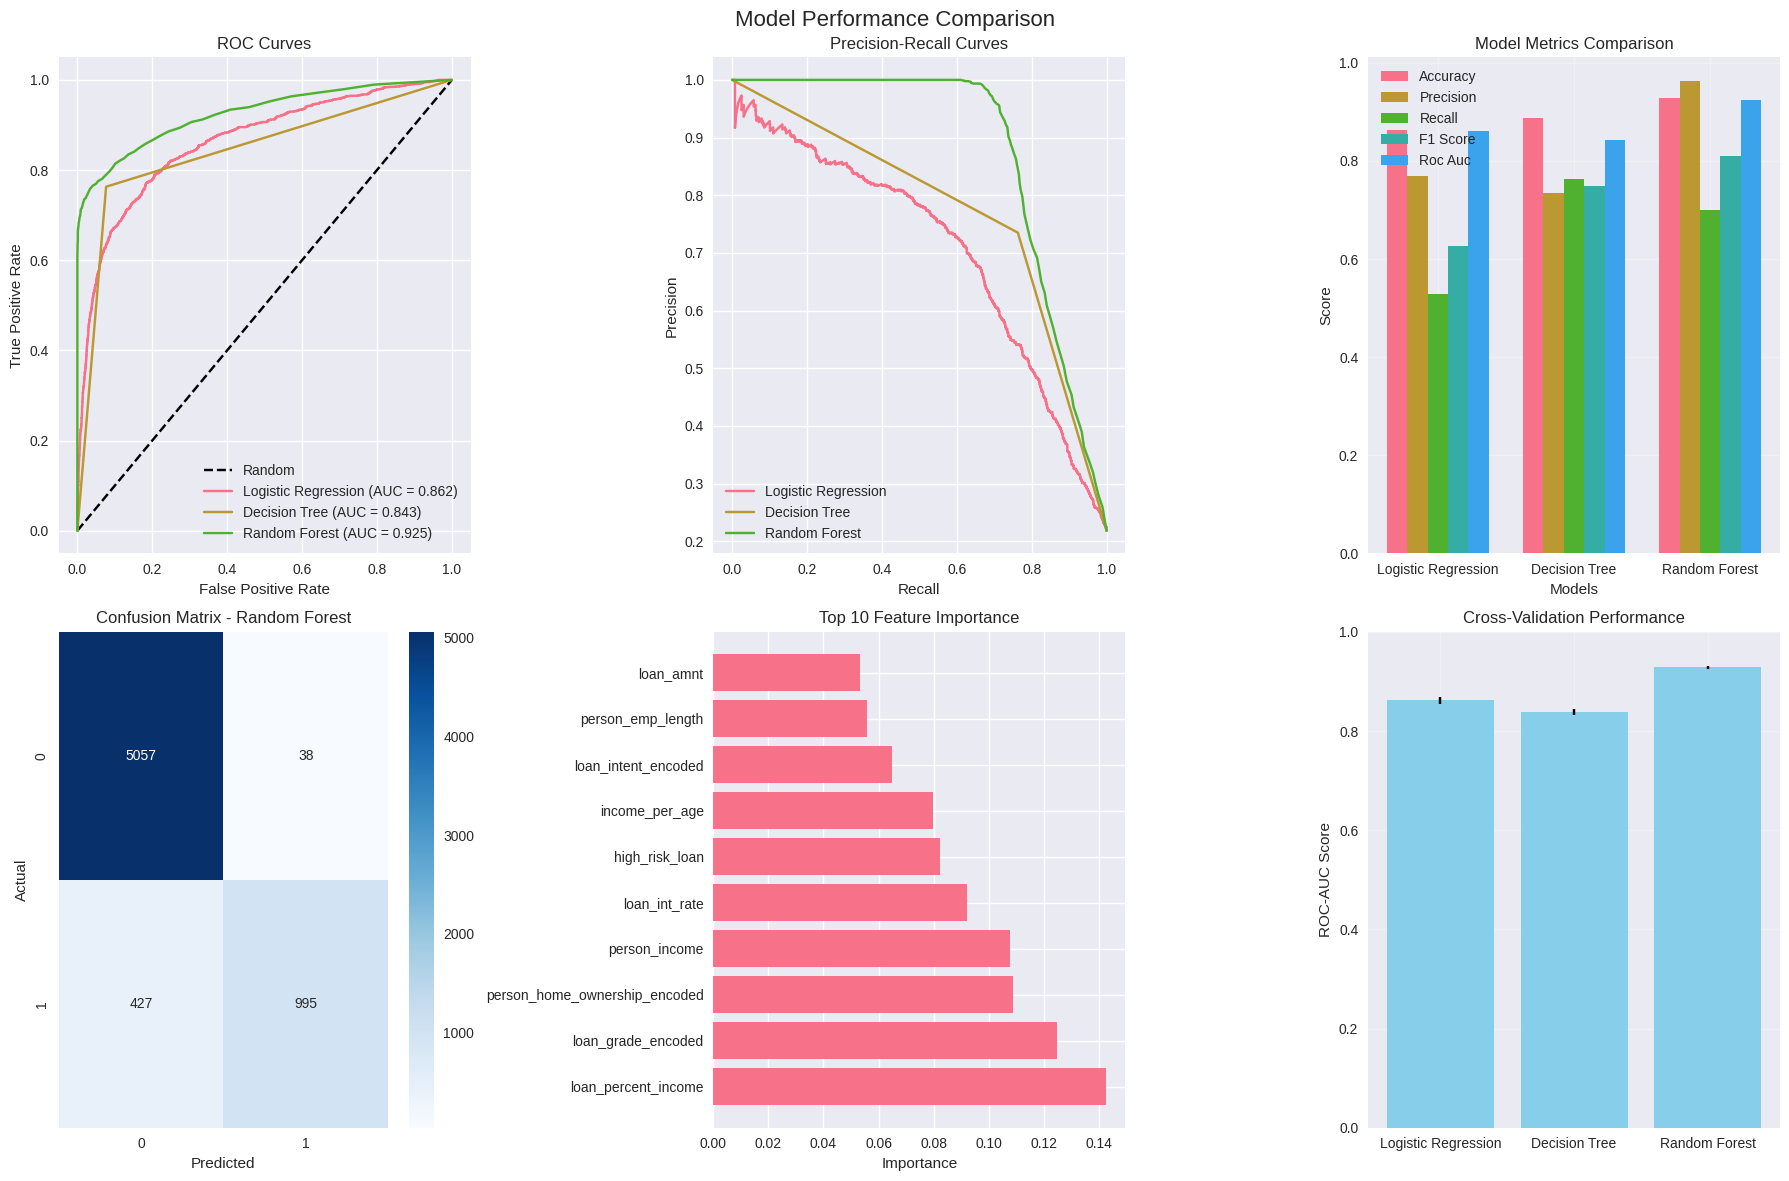

In [13]:

def visualize_results(results, X_test, y_test, feature_names):
    """Create comprehensive visualizations of results"""
    print("\n" + "=" * 60)
    print("STEP 6: RESULTS VISUALIZATION")
    print("=" * 60)

    # Model comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Model Performance Comparison', fontsize=16)

    # 1. ROC Curves
    axes[0, 0].plot([0, 1], [0, 1], 'k--', label='Random')
    for name, result in results.items():
        fpr, tpr, _ = roc_curve(y_test, result['y_pred_proba'])
        axes[0, 0].plot(fpr, tpr, label=f'{name} (AUC = {result["roc_auc"]:.3f})')
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].set_title('ROC Curves')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # 2. Precision-Recall Curves
    for name, result in results.items():
        precision, recall, _ = precision_recall_curve(y_test, result['y_pred_proba'])
        axes[0, 1].plot(recall, precision, label=f'{name}')
    axes[0, 1].set_xlabel('Recall')
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].set_title('Precision-Recall Curves')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # 3. Model Metrics Comparison
    metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
    model_names = list(results.keys())

    x_pos = np.arange(len(model_names))
    width = 0.15

    for i, metric in enumerate(metrics):
        values = [results[name][metric] for name in model_names]
        axes[0, 2].bar(x_pos + i * width, values, width, label=metric.replace('_', ' ').title())

    axes[0, 2].set_xlabel('Models')
    axes[0, 2].set_ylabel('Score')
    axes[0, 2].set_title('Model Metrics Comparison')
    axes[0, 2].set_xticks(x_pos + width * 2)
    axes[0, 2].set_xticklabels(model_names)
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # 4. Confusion Matrix for best model (Random Forest)
    best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
    cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
    axes[1, 0].set_title(f'Confusion Matrix - {best_model_name}')
    axes[1, 0].set_xlabel('Predicted')
    axes[1, 0].set_ylabel('Actual')

    # 5. Feature Importance (Random Forest)
    if best_model_name == 'Random Forest':
        feature_importance = results[best_model_name]['model'].feature_importances_
        feature_df = pd.DataFrame({
            'feature': feature_names,
            'importance': feature_importance
        }).sort_values('importance', ascending=False).head(10)

        axes[1, 1].barh(range(len(feature_df)), feature_df['importance'])
        axes[1, 1].set_yticks(range(len(feature_df)))
        axes[1, 1].set_yticklabels(feature_df['feature'])
        axes[1, 1].set_xlabel('Importance')
        axes[1, 1].set_title('Top 10 Feature Importance')

    # 6. Cross-validation scores
    cv_means = [results[name]['cv_mean'] for name in model_names]
    cv_stds = [results[name]['cv_std'] for name in model_names]

    axes[1, 2].bar(model_names, cv_means, yerr=cv_stds, capsize=5, color='skyblue')
    axes[1, 2].set_ylabel('ROC-AUC Score')
    axes[1, 2].set_title('Cross-Validation Performance')
    axes[1, 2].set_ylim(0, 1)
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

visualize_results(results, X_test, y_test, X.columns)

### 7. FINAL SUMMARY AND RECOMMENDATIONS

In [14]:
def generate_final_report(results, best_model, X_test, y_test):
    """Generate final model report and recommendations"""
    print("\n" + "=" * 80)
    print("FINAL MODEL REPORT & RECOMMENDATIONS")
    print("=" * 80)

    # Best model selection
    best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])
    best_result = results[best_model_name]

    print(f"BEST MODEL: {best_model_name}")
    print(f"ROC-AUC Score: {best_result['roc_auc']:.4f}")
    print(f"Accuracy: {best_result['accuracy']:.4f}")
    print(f"Precision: {best_result['precision']:.4f}")
    print(f"Recall: {best_result['recall']:.4f}")
    print(f"F1-Score: {best_result['f1_score']:.4f}")

    print("\nMODEL INTERPRETATION:")
    print("• High ROC-AUC indicates good discrimination between good and bad loans")
    print("• Precision shows how many predicted defaults are actually defaults")
    print("• Recall shows how many actual defaults are correctly identified")

    print("\nBUSINESS RECOMMENDATIONS:")
    print("1. Deploy the Random Forest model for credit scoring")
    print("2. Focus on high-importance features for decision making")
    print("3. Monitor model performance regularly and retrain as needed")
    print("4. Consider ensemble methods for even better performance")
    print("5. Implement proper model governance and bias monitoring")

    print("\nRISK CONSIDERATIONS:")
    print("• False positives: Rejecting good customers (lost revenue)")
    print("• False negatives: Approving bad customers (credit losses)")
    print("• Adjust threshold based on business risk tolerance")

    # Classification report
    print("\nDETAILED CLASSIFICATION REPORT:")
    print(classification_report(y_test, best_result['y_pred']))


generate_final_report(results, best_model, X_test, y_test)


FINAL MODEL REPORT & RECOMMENDATIONS
BEST MODEL: Random Forest
ROC-AUC Score: 0.9252
Accuracy: 0.9286
Precision: 0.9632
Recall: 0.6997
F1-Score: 0.8106

MODEL INTERPRETATION:
• High ROC-AUC indicates good discrimination between good and bad loans
• Precision shows how many predicted defaults are actually defaults
• Recall shows how many actual defaults are correctly identified

BUSINESS RECOMMENDATIONS:
1. Deploy the Random Forest model for credit scoring
2. Focus on high-importance features for decision making
3. Monitor model performance regularly and retrain as needed
4. Consider ensemble methods for even better performance
5. Implement proper model governance and bias monitoring

RISK CONSIDERATIONS:
• False positives: Rejecting good customers (lost revenue)
• False negatives: Approving bad customers (credit losses)
• Adjust threshold based on business risk tolerance

DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.92    

### 8. PREDICTION FUNCTION FOR NEW DATA

In [17]:
def make_predictions(new_data, best_model, scaler, feature_columns, le_dict=None):
    """Make predictions on new loan applications"""
    print("\n" + "=" * 60)
    print("MAKING PREDICTIONS ON NEW DATA")
    print("=" * 60)

    # Make a copy of new data
    data = new_data.copy()

    # Apply the same preprocessing as training data
    print("Preprocessing new data...")

    # Handle missing values
    numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                      'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

    for col in numerical_cols:
        if col in data.columns and data[col].isnull().sum() > 0:
            data[col] = data[col].fillna(data[col].median())

    # Feature engineering (same as training)
    if 'person_age' in data.columns and 'person_income' in data.columns:
        # Age groups
        data['age_group'] = pd.cut(data['person_age'],
                                  bins=[0, 25, 35, 45, 55, 100],
                                  labels=['Young', 'Adult', 'Middle', 'Senior', 'Elder'])

        # Income brackets
        data['income_bracket'] = pd.cut(data['person_income'],
                                       bins=5,
                                       labels=['Low', 'Low-Mid', 'Mid', 'Mid-High', 'High'])

        # High risk loan
        if 'loan_percent_income' in data.columns:
            data['high_risk_loan'] = (data['loan_percent_income'] > 0.3).astype(int)

        # Income to age ratio
        data['income_per_age'] = data['person_income'] / data['person_age']

        # Loan amount brackets
        if 'loan_amnt' in data.columns:
            data['loan_size'] = pd.cut(data['loan_amnt'],
                                      bins=[0, 5000, 15000, 25000, float('inf')],
                                      labels=['Small', 'Medium', 'Large', 'Very Large'])

    # Encode categorical variables (simplified for prediction)
    categorical_columns = ['person_home_ownership', 'loan_intent', 'loan_grade',
                          'cb_person_default_on_file', 'age_group', 'income_bracket', 'loan_size']

    for col in categorical_columns:
        if col in data.columns:
            le = LabelEncoder()
            data[col + '_encoded'] = le.fit_transform(data[col].astype(str))

    # Select the same features used in training
    try:
        X_new = data[feature_columns]

        # Handle missing values and infinite values
        X_new = X_new.replace([np.inf, -np.inf], np.nan)
        for col in X_new.columns:
            if X_new[col].isnull().sum() > 0:
                if X_new[col].dtype in [np.float64, np.int64]:
                    X_new[col] = X_new[col].fillna(X_new[col].median())
                else:
                    X_new[col] = X_new[col].fillna(0)  # Default for missing encoded values

        # Scale the features
        X_new_scaled = scaler.transform(X_new)

        # Make predictions
        predictions_proba = best_model.predict_proba(X_new_scaled)[:, 1]
        predictions_binary = best_model.predict(X_new_scaled)

        # Create results DataFrame
        results_df = pd.DataFrame({
            'Default_Probability': predictions_proba,
            'Predicted_Default': predictions_binary,
            'Risk_Category': pd.cut(predictions_proba,
                                   bins=[0, 0.3, 0.6, 1.0],
                                   labels=['Low Risk', 'Medium Risk', 'High Risk'])
        })

        print(f"Predictions completed for {len(results_df)} records")
        print(f"Average default probability: {predictions_proba.mean():.4f}")
        print(f"High risk applications: {(predictions_proba > 0.6).sum()}")

        return results_df, predictions_proba

    except Exception as e:
        print(f"Error in prediction: {str(e)}")
        print("Make sure new_data has the same structure as training data")
        return None, None


### 9. CREATE SAMPLE NEW DATA FOR DEMONSTRATION

In [18]:
def create_sample_new_data():
    """Create sample new loan applications for demonstration"""

    sample_data = pd.DataFrame({
        'person_age': [25, 35, 45, 28, 52],
        'person_income': [50000, 75000, 120000, 35000, 85000],
        'person_home_ownership': ['RENT', 'MORTGAGE', 'OWN', 'RENT', 'MORTGAGE'],
        'person_emp_length': [2, 8, 15, 1, 10],
        'loan_intent': ['PERSONAL', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION', 'EDUCATION', 'MEDICAL'],
        'loan_grade': ['C', 'B', 'A', 'D', 'B'],
        'loan_amnt': [15000, 25000, 50000, 8000, 30000],
        'loan_int_rate': [12.5, 8.9, 6.2, 18.4, 9.8],
        'loan_percent_income': [0.30, 0.33, 0.42, 0.23, 0.35],
        'cb_person_default_on_file': ['N', 'N', 'N', 'Y', 'N'],
        'cb_person_cred_hist_length': [3, 12, 20, 2, 15]
    })

    return sample_data


In [19]:
# Step 1: Choose best model
best_model_name = max(results, key=lambda name: results[name]['roc_auc'])
best_model = results[best_model_name]['model']
print(f"Using best model: {best_model_name}")

# Step 2: Get feature columns used in training
feature_columns = X.columns.tolist()

# Step 3: Create new sample data
new_data = create_sample_new_data()

# Step 4: Make predictions
results_df, predictions_proba = make_predictions(
    new_data=new_data,
    best_model=best_model,
    scaler=scaler,
    feature_columns=feature_columns
)

# Step 5: View results
print(results_df)


Using best model: Random Forest

MAKING PREDICTIONS ON NEW DATA
Preprocessing new data...
Predictions completed for 5 records
Average default probability: 0.8940
High risk applications: 5
   Default_Probability  Predicted_Default Risk_Category
0                 0.88                  1     High Risk
1                 0.89                  1     High Risk
2                 0.91                  1     High Risk
3                 0.88                  1     High Risk
4                 0.91                  1     High Risk
